# Лабораторна робота №3
## Візуалізація даних

### Мета роботи
Ознайомитися з методами очищення та візуалізації даних за допомогою Python та бібліотек Pandas, Matplotlib і Seaborn.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race",
    "sex", "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]

df = pd.read_csv("adult.data", names=columns, sep=",", skipinitialspace=True)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Опис датасету

Було використано датасет Adult Income з репозиторію UCI.
Він містить інформацію про вік, освіту, роботу, кількість робочих годин та рівень доходу.
Датасет містить як числові, так і категоріальні змінні, а також пропущені значення.

In [4]:
# Cleaning
df.replace("?", np.nan, inplace=True)
df_clean = df.dropna()

print("Було:", df.shape[0])
print("Стало:", df_clean.shape[0])

df_clean.isnull().sum()

Було: 32561
Стало: 30162


age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

## Візуалізація даних

Було побудовано декілька графіків для аналізу структури даних та залежностей між змінними.

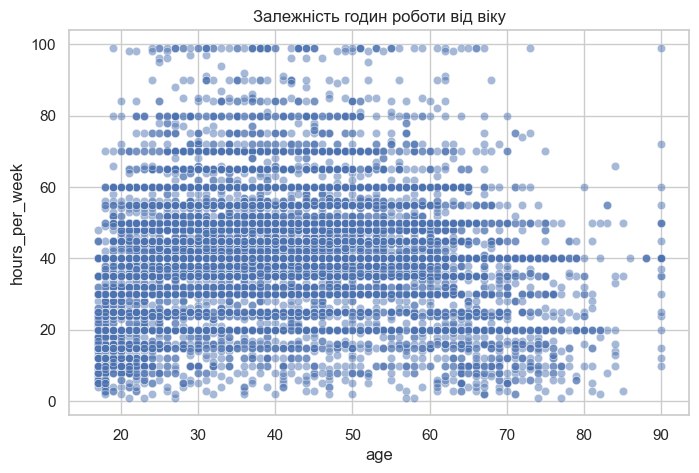

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="age", y="hours_per_week", alpha=0.5)
plt.title("Залежність годин роботи від віку")
plt.show()

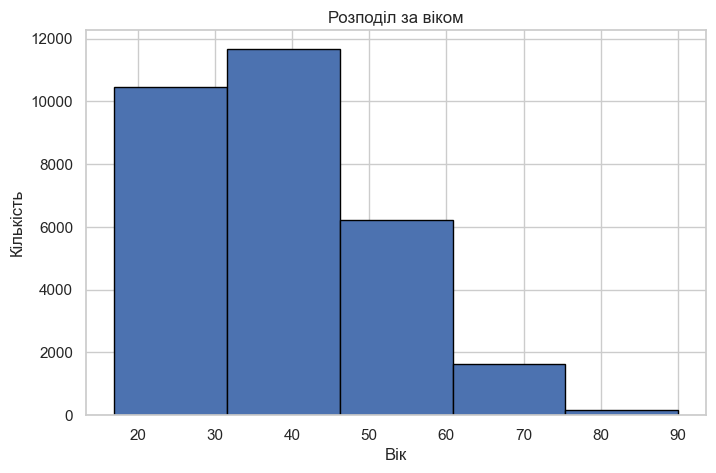

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df_clean["age"], bins=5, edgecolor="black")
plt.title("Розподіл за віком")
plt.xlabel("Вік")
plt.ylabel("Кількість")
plt.show()

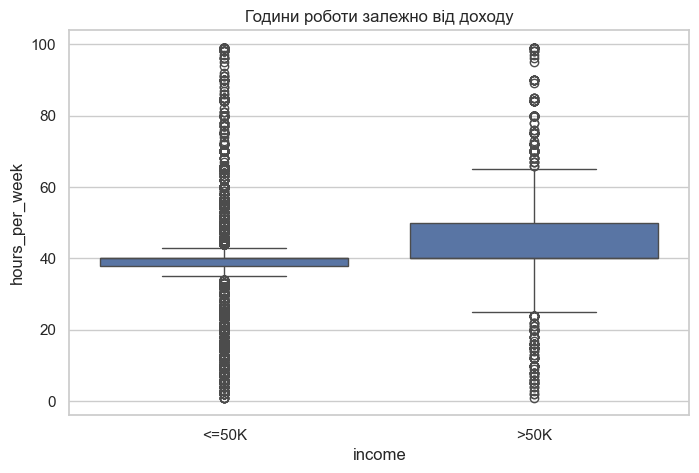

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="income", y="hours_per_week")
plt.title("Години роботи залежно від доходу")
plt.show()

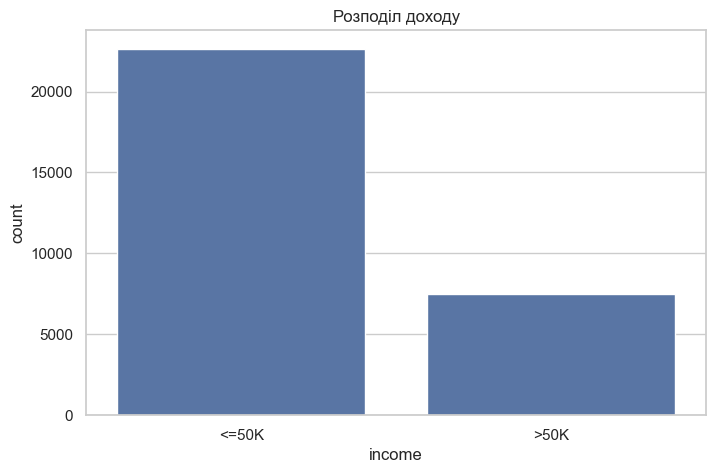

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="income")
plt.title("Розподіл доходу")
plt.show()

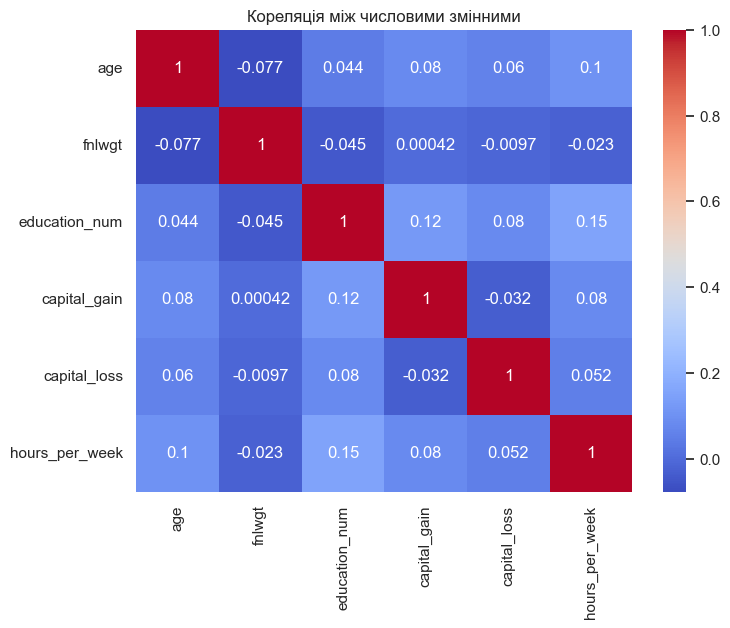

In [9]:
plt.figure(figsize=(8,6))
corr = df_clean[["age","fnlwgt","education_num","capital_gain","capital_loss","hours_per_week"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Кореляція між числовими змінними")
plt.show()

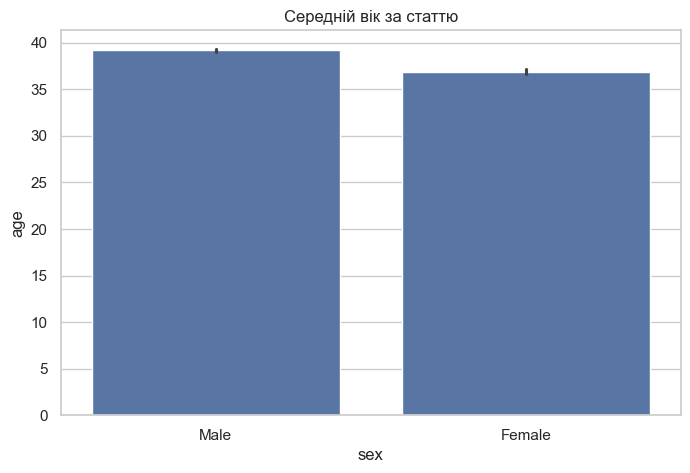

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x="sex", y="age")
plt.title("Середній вік за статтю")
plt.show()

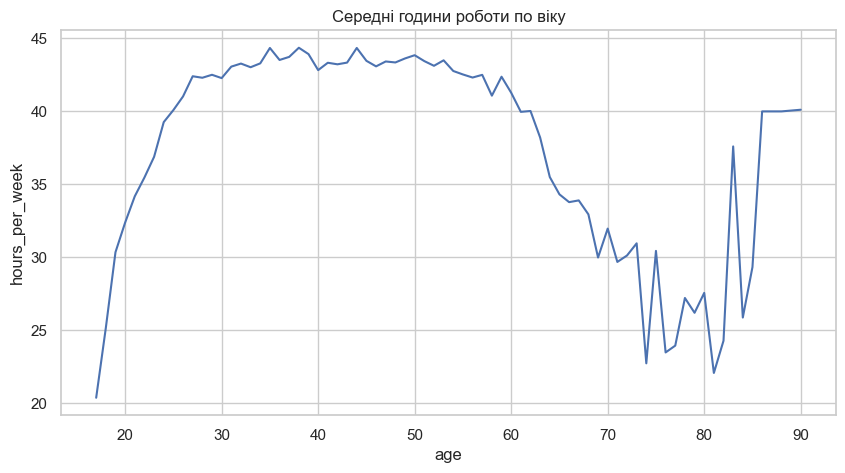

In [11]:
age_hours = df_clean.groupby("age")["hours_per_week"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=age_hours, x="age", y="hours_per_week")
plt.title("Середні години роботи по віку")
plt.show()

## Висновок

У ході роботи було очищено датасет та побудовано графіки, які дозволили проаналізувати розподіл даних та залежності між змінними. Використання бібліотек Python дозволило ефективно візуалізувати дані.